In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
from scipy import stats

In [2]:
df = pd.read_csv("./dataset/Titanic-Dataset.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
print(f"Shape: {df.shape}")
df.isna().sum()

Shape: (891, 12)


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [4]:
df.drop(columns=['Cabin'],inplace=True)

In [5]:
df = df.dropna()

In [6]:
print(f"Shape: {df.shape}")
df.isna().sum()

Shape: (712, 11)


PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

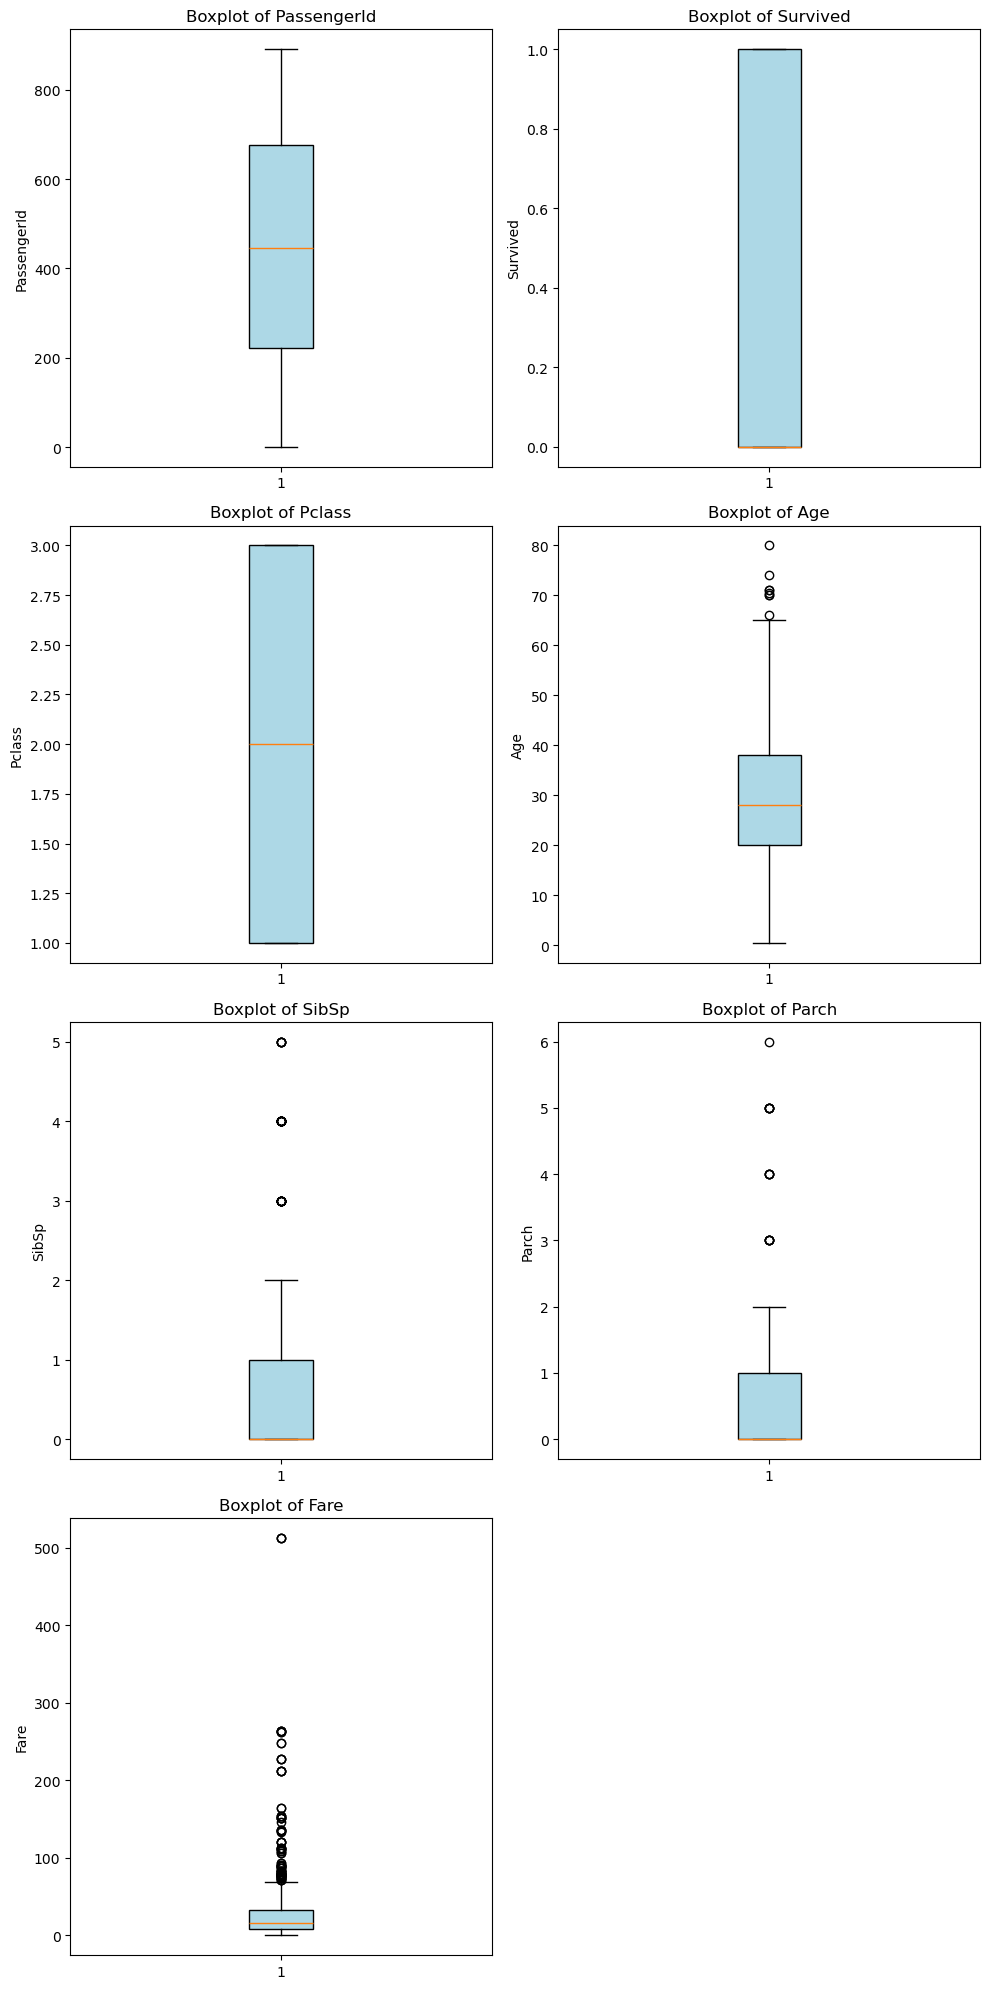

In [7]:
# Before outlier removal
numeric_cols = df.select_dtypes(include=[np.number]).columns
num_cols = len(numeric_cols)
num_rows = (num_cols + 1) // 2
fig, axes = plt.subplots(num_rows, 2, figsize=(10, 5 * num_rows))

axes = axes.flatten()

# Plot boxplots
for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df[col], vert=True, patch_artist=True, boxprops=dict(facecolor='lightblue'))
    axes[i].set_title(f'Boxplot of {col}')
    axes[i].set_ylabel(col)

# Hide unused subplots (if odd number of columns)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])  # Removes empty subplot spaces

plt.tight_layout()
plt.show()

In [8]:
# Remove outlier
# Compute Z-scores and filter without adding a new column
print(df.shape)
for i in ['Age','SibSp','Parch','Fare']:
    df = df[np.abs(stats.zscore(df[i])) < 3]
print(df.shape)

# correlation (heatmap), bar (categorcal), normalize (

(712, 11)
(655, 11)
